Mohammad hossein beglari 40003413 

In [2]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt 

In [30]:
img1= cv2.imread('img1.png',cv2.IMREAD_GRAYSCALE)
img2=cv2.imread('img2.png',cv2.IMREAD_GRAYSCALE)
img3=cv2.imread('img3.png',cv2.IMREAD_GRAYSCALE)
img4=cv2.imread('noisy.png',cv2.IMREAD_GRAYSCALE)
img5=cv2.imread('pure image.tif',cv2.IMREAD_GRAYSCALE)

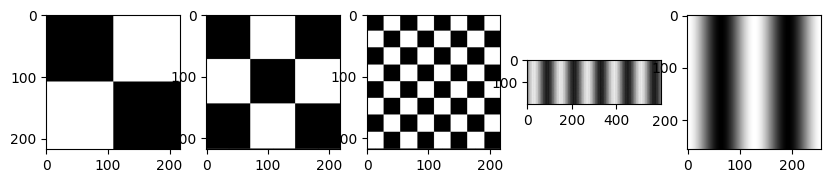

In [26]:
plt.figure(figsize=(10, 6))
plt.subplot(151),plt.imshow(img1,cmap='gray')
plt.subplot(152),plt.imshow(img2,cmap='gray')
plt.subplot(153),plt.imshow(img3,cmap='gray')
plt.subplot(154),plt.imshow(img4,cmap='gray')
plt.subplot(155),plt.imshow(img5,cmap='gray')
plt.show()

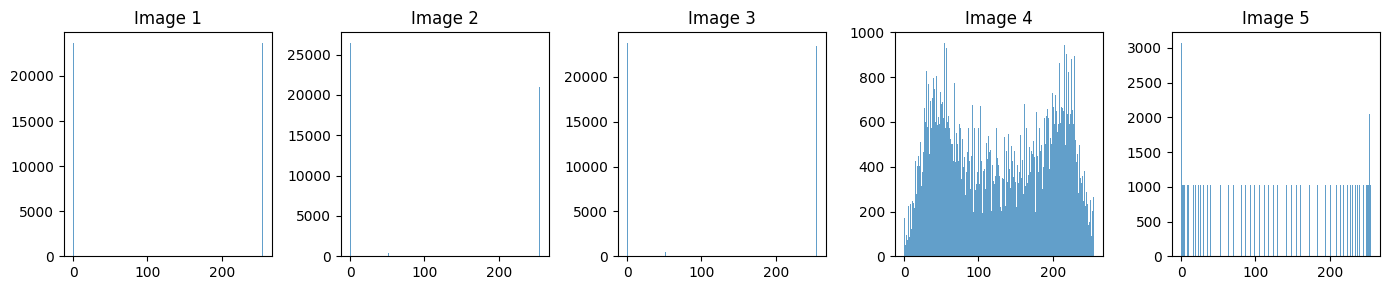

In [35]:
plt.figure(figsize=(14, 3)) 

plt.subplot(151), plt.hist(img1.flatten(), bins=256, alpha=0.7, rwidth=1)
plt.title('Image 1')

plt.subplot(152), plt.hist(img2.flatten(), bins=256, alpha=0.7, rwidth=1)
plt.title('Image 2')

plt.subplot(153), plt.hist(img3.flatten(), bins=256, alpha=0.7, rwidth=1)
plt.title('Image 3')

plt.subplot(154), plt.hist(img4.flatten(), bins=256, alpha=0.7, rwidth=1)
plt.title('Image 4')

plt.subplot(155), plt.hist(img5.flatten(), bins=256, alpha=0.7, rwidth=1)
plt.title('Image 5')

plt.tight_layout()  
plt.show()

تصاویر اول تا سوم تنها با اعداد صفر و 255 تشکیل شدند و وجود هیچ نویزی در انها دیده نمیشود ... هم از طریق خود تصاویر میتوان پی برد هم از همگونی و تقارن فضای فوریه آنها 

تصویر اخر نیز درست است که تنها از مقادیر صفر و 255 تشکیل نشده ولی از هیستوگرام همگن و فضای فوریه آن میتوان فهمید یک تصویر مات هست و نه دارای نویز 

با توجه به هیستوگرام ها و فضای فوریه نا همگون تصویر متوجه وجود نویز در تصویر 3 می شویم و برای رفع ان باید از یک فیلتر استفاده کرد که در اینجا از فیلتر گوسین استفاده میکنیم . 

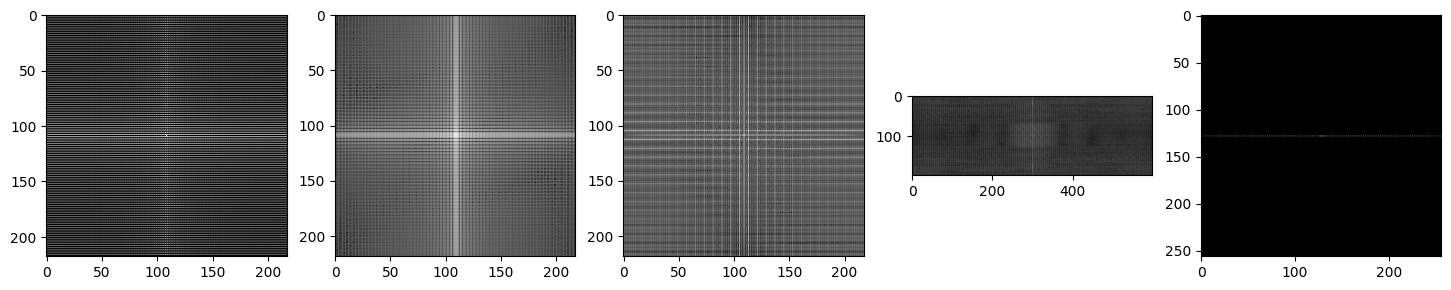

In [52]:
f1 = np.fft.fft2(img1)
f2 = np.fft.fft2(img2)
f3 = np.fft.fft2(img3)
f4 = np.fft.fft2(img4)
f5 = np.fft.fft2(img5)
fshift1 = np.fft.fftshift(f1)
fshift2 = np.fft.fftshift(f2)
fshift3 = np.fft.fftshift(f3)
fshift4 = np.fft.fftshift(f4)
fshift5 = np.fft.fftshift(f5)
magnitude_spectrum1 = np.log(np.abs(fshift1) + 1)
magnitude_spectrum2 = np.log(np.abs(fshift2) + 1)
magnitude_spectrum3 = np.log(np.abs(fshift3) + 1)
magnitude_spectrum4 = np.log(np.abs(fshift4) + 1)
magnitude_spectrum5 = np.log(np.abs(fshift5) + 1)
plt.figure(figsize=(18, 10))
plt.subplot(151), plt.imshow(magnitude_spectrum1, cmap='gray')
plt.subplot(152), plt.imshow(magnitude_spectrum2, cmap='gray')
plt.subplot(153), plt.imshow(magnitude_spectrum3, cmap='gray')
plt.subplot(154), plt.imshow(magnitude_spectrum4, cmap='gray')
plt.subplot(155), plt.imshow(magnitude_spectrum5, cmap='gray')
plt.show()

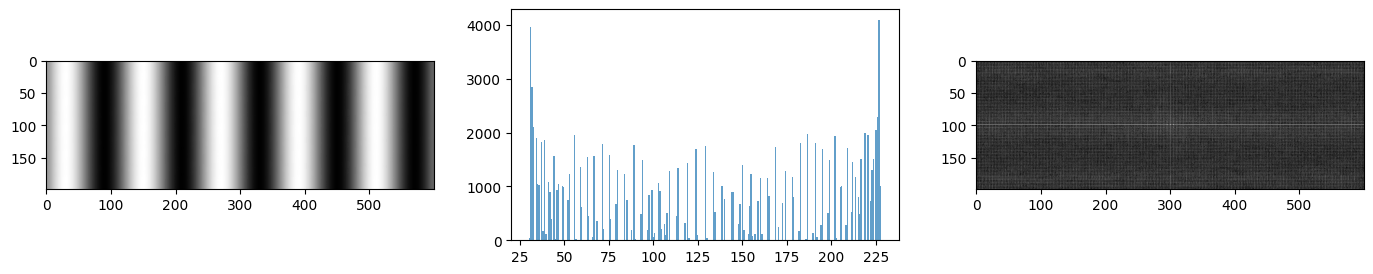

In [51]:
plt.figure(figsize=(17,3))

blurred_image = cv2.GaussianBlur(img4, (21,21), 0)
f4_1 = np.fft.fft2(blurred_image)
fshift4_1 = np.fft.fftshift(f4_1)
magnitude_spectrum4_1 = np.log(np.abs(fshift4_1) + 1)

plt.subplot(131), plt.imshow(blurred_image, cmap='gray')
plt.subplot(132), plt.hist(blurred_image.flatten(), bins=256, alpha=0.7, rwidth=1)
plt.subplot(133), plt.imshow(magnitude_spectrum4_1, cmap='gray')
plt.show()

پس از اعمال فیلتر و رسم هیستوگرام آن و ترسیم فضای فوریه مشاهده میکنیم مشاهده میکنیم که هم توضیع هیستوگرام کمتر شده 
و تصویر فضای فوریه همگن تر شده است و متقارن و این یعنی تا حد قابل قبولی موفق به حذف نویز گشته ایم . 